## ポアソン分布のλの事後分布と事後統計量

## ポアソン分布
+ x = 0, 1, 2, ...
+ λ > 0
$$ p(x|\lambda) = \frac{\lambda^{x}e^{-\lambda}}{x!} $$

## ガンマ分布
+ x > 0
+ $ \alpha > 0 $
+ $ \theta > 0 $
$$ p(x |\alpha,\theta) = \frac{x^{\alpha-1}e^{-\frac{x}{\theta}}}{\Gamma(\alpha)\theta^{\alpha}} $$

### ガンマ関数
$$ \Gamma(x) = \int_{0}^{\infty}z^{x-1}e^{-z}dz  $$


## ベイズ統計学におけるガンマ関数
$$ Ga(\alpha,\beta) = p(x | \alpha, \beta) = \frac{\beta^{\alpha}}{\Gamma(\alpha)}x^{\alpha-1}e^{-\beta x} $$
$$ \lambda \sim Ga(\alpha_{0},\beta_{0}) $$

## ポアソン分布の尤度
$$ p(D|\lambda) = \prod_{i=1}^{n}p(x_{i}|\lambda) = \prod_{i=1}^{n}\frac{\lambda^{x_i}e^{-\lambda}}{x_i!} = \frac{\lambda^{\sum_{i=1}^{n}x}e^{-n\lambda}}{\prod_{i=1}^{n}x_i!} $$


## ベイズの定理
$$ p(\lambda|D) \propto p(D|\lambda)p(\lambda) $$
$$ \propto \lambda^{\sum_{i=1}^{n}x_{i}}e^{-n\lambda} \times \lambda^{\alpha_{0}-1}e^{-\beta_{0}\lambda} $$
$$ \propto \lambda^{\sum_{i=1}^{n}x_{i} + \alpha_{0} -1}e^{-(n + \beta_{0}) \lambda} $$
+ $ \alpha_{*} = \sum_{i=1}^{n}x_{i} + \alpha_{0} $
+ $ \beta_{*} = n + \beta_{0} $
+ $ \lambda | D \sim Ga(\alpha_{*},\beta_{*}) $

## ポアソン分布の予測分布
+ 負の二項分布になる
$$  
p(\tilde{x}|D) = 
\begin{pmatrix}
   \tilde{x} + \alpha_{*} - 1 \\
   \alpha_{*} - 1
\end{pmatrix}
(\frac{\beta_{*}}{\beta_{*} + 1})^{\alpha_{*}}
(\frac{1}{\beta_{*} + 1})^{\tilde{x}}
$$

In [2]:
import numpy as np
np.set_printoptions(precision=3)
import scipy as sp
import scipy.stats as st
import scipy.optimize as opt
import matplotlib.pyplot as plt
import japanize_matplotlib
%matplotlib inline
# import pymc
import psutil
import pandas as pd

In [3]:
# ガンマ分布のHPD区間の計算
def gamma_hpdi(ci0, alpha, theta, prob):
    """
    Args:
        ci0 (_type_): 初期値
        alpha (_type_): 形状パラメータ
        theta (_type_): 尺度パラメータ
        prob (_type_): HPD区間の確率(0 < prob < 1) = (1 - c)
    """
    def hpdi_conditions(v, a, t, p):
        # 累積確率密度 CDF(b_c) - CDF(a_c) - (1-c) = 0
        eq1 = st.gamma.cdf(v[1], a, scale=t) - st.gamma.cdf(v[0], a, scale=t) - p
        # 確率密度 PDF(a_c|D) - PDF(b_c|D) = 0
        eq2 = st.gamma.pdf(v[1], a, scale=t) - st.gamma.pdf(v[0], a, scale=t)

        return np.hstack((eq1, eq2))
    
    return opt.root(hpdi_conditions, ci0, args=(alpha, theta, prob)).x

In [4]:
# ポアソン分布のパラメータの事後統計量の計算
def poisson_stats(data: np.ndarray, a0: float, b0: float, prob: float):
    """

    Args:
        data (np.ndarray): _description_
        a0 (float): 事前分布の形状パラメータ
        b0 (float): 事前分布の尺度パラメータの逆数
        prob (float): 区間確率

        results: 事後統計量のデータフレーム
        a_star: 事後分布の形状パラメータ
        b_star: 事後分布の尺度パラメータの逆数
    """
    n = data.size
    a_star = data.sum() + a0
    b_star = n + b0
    theta_star = 1.0 / b_star

    mean_lam = st.gamma.mean(a_star, scale=theta_star)
    median_lam = st.gamma.median(a_star, scale=theta_star)
    mode_lam = (a_star - 1.0) * theta_star
    sd_lam = st.gamma.std(a_star, scale=theta_star)
    ci_lam = st.gamma.interval(prob, a_star, scale=theta_star)
    hpdi_lamb = gamma_hpdi(ci_lam, a_star, theta_star, prob)
    stats = np.hstack((mean_lam, median_lam, mode_lam, sd_lam, ci_lam, hpdi_lamb)).reshape((1,8))
    stats_string = [
        '平均', '中央値', '最頻値', '標準偏差', '信用区間(下限)', '信用区間(上限)', 'HPD区間(下限)', 'HPD区間(上限)'
    ]
    param_string = ['$\\lambda$']
    results = pd.DataFrame(stats, index=param_string, columns=stats_string)
    return results, a_star, b_star

ポアソン分布からデータ生成

In [5]:
lam = 3.0
n = 50
np.random.seed(99)
data = st.poisson.rvs(lam, size=n)
data

array([3, 3, 1, 5, 2, 3, 4, 1, 1, 1, 1, 4, 0, 6, 3, 6, 5, 1, 3, 1, 5, 4,
       2, 4, 1, 2, 5, 2, 3, 2, 4, 4, 5, 4, 3, 4, 2, 1, 2, 7, 4, 1, 3, 4,
       2, 3, 2, 1, 2, 5], dtype=int64)

事後統計量の計算

In [6]:
a0 = 1.0
b0 = 1.0
prob = 0.95
results, a_star, b_star = poisson_stats(data, a0, b0, prob)
print(results.to_string(float_format='{:,.4f}'.format))

              平均    中央値    最頻値   標準偏差  信用区間(下限)  信用区間(上限)  HPD区間(下限)  HPD区間(上限)
$\lambda$ 2.9020 2.8954 2.8824 0.2385    2.4533    3.3878     2.4409     3.3740


事後分布のグラフ作成

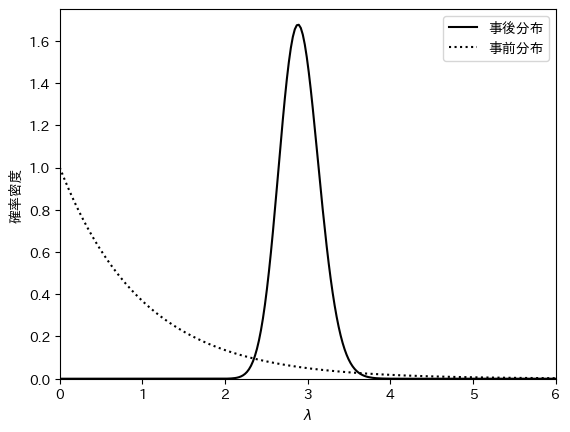

In [7]:
fig = plt.figure(num=1, facecolor='w')
x = np.linspace(0, 6, 250)
plt.plot(x, st.gamma.pdf(x, a_star, scale=1.0/b_star), 'k-', label='事後分布')
plt.plot(x, st.gamma.pdf(x, a0, scale=1.0/b0), 'k:', label='事前分布')
plt.xlim(0, 6)
plt.ylim(0, 1.75)
plt.xlabel('$\\lambda$')
plt.ylabel('確率密度')
plt.legend(loc='best')
# plt.savefig('pybayes_fig_poisson_posterior.png', dpi=300)
plt.show()